# EDA 

* Acquire WRDS Data
* Clean said Data
* Plot to analyze basic trends

# ───────────────────────────────────────────────────────────────────────────────
# WRDS to PostgreSQL Pipeline
# Project IPCA on U.S. Micro-Cap Equities
## Author  : Bennie Reynolds, Clemson University

### Tables created in PostgreSQL
### ────────────────────────────
 * raw.crsp_monthly       — CRSP msf + msenames (returns, prices, market cap)
 * raw.compustat_annual   — Compustat funda (accounting fundamentals)
 * raw.rf                 — Monthly risk-free rate (Fama-French)
 * raw.bidask             — Monthly bid-ask spread (from CRSP dsf)
 * main.panel             — Merged panel: micro-cap flag, all 13 characteristics
                           rank-standardized within each month

### Dependencies
### ────────────
  ### pip install wrds pandas numpy psycopg2-binary sqlalchemy

## Usage
## ─────
  ### 1. Set DB_URL below (or export MICROCAP_DB_URL as an env variable)
  ### 2. python EDA.ipynb

# imports

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
load_dotenv()
DB_URL = os.getenv("DB_URL")

import numpy as np
import pandas as pd
import wrds
from sqlalchemy import create_engine, text
import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
START_DATE = "1990-01-01"
END_DATE   = "2023-12-31"

PCT_LO = 5
PCT_HI = 20

In [4]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
OUTPUT_DIR = "./eda_output"
START_DATE = "1990-01-01"     
END_DATE   = "2023-12-31"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Data Pipeline

In [5]:
db = wrds.Connection()

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [6]:

from sqlalchemy import create_engine
engine = create_engine(DB_URL)

# load cached datasets
crsp   = pd.read_sql_table("crsp_monthly", engine, schema="raw", parse_dates=["date"])
rf     = pd.read_sql_table("rf", engine, schema="raw", parse_dates=["date"])
comp   = pd.read_sql_table("compustat_annual", engine, schema="raw", parse_dates=["datadate"])
bidask = pd.read_sql_table("bidask", engine, schema="raw", parse_dates=["date"])

print("loaded shapes:", crsp.shape, rf.shape, comp.shape, bidask.shape)

loaded shapes: (2021395, 17) (408, 3) (316956, 11) (3084239, 4)


In [ ]:
crsp = db.raw_sql("""
    SELECT
        a.permno,
        a.date,
        a.ret,
        a.prc,
        a.shrout,
        ABS(a.prc) * a.shrout   AS mktcap,
        a.vol,
        b.exchcd,
        b.shrcd,
        b.cusip,
        b.ticker,
        b.comnam
    FROM crsp.msf      AS a
    JOIN crsp.msenames AS b
      ON  a.permno  = b.permno
      AND b.namedt <= a.date
      AND a.date   <= COALESCE(b.nameendt, CURRENT_DATE)
    WHERE a.date   BETWEEN '1990-01-01' AND '2023-12-31'
      AND b.shrcd  IN (10, 11)
      AND b.exchcd IN (1, 2, 3)
      AND a.ret    IS NOT NULL
""", date_cols=["date"])

crsp["mktcap"] = crsp["mktcap"].abs() / 1000  # convert to $M
print(crsp.shape)
crsp.head()

In [ ]:
rf = db.raw_sql("""
    SELECT date, rf
    FROM ff.factors_monthly
    WHERE date BETWEEN '1990-01-01' AND '2023-12-31'
""", date_cols=["date"])

print(rf.shape)
rf.head()

(408, 2)


,date,rf
0,1990-01-01,0.0057
1,1990-02-01,0.0057
2,1990-03-01,0.0064
3,1990-04-01,0.0069
4,1990-05-01,0.0068


In [ ]:
comp = db.raw_sql("""
    SELECT
        gvkey,
        cusip,
        datadate,
        at      AS total_assets,
        ceq     AS book_equity,
        ni      AS net_income,
        gp      AS gross_profit,
        dltt    AS long_term_debt,
        dlc     AS short_term_debt
    FROM comp.funda
    WHERE datadate BETWEEN '1990-01-01' AND '2023-12-31'
      AND indfmt  = 'INDL'
      AND datafmt = 'STD'
      AND popsrc  = 'D'
      AND consol  = 'C'
      AND at > 0
""", date_cols=["datadate"])

print(comp.shape)
comp.head()

(316956, 9)


,gvkey,cusip,datadate,total_assets,book_equity,net_income,gross_profit,long_term_debt,short_term_debt
0,001003,000354100,1990-01-31,10.109,-0.416,-0.221,7.384,0.076,4.449
1,001004,000361105,1990-05-31,388.521,189.548,25.655,107.944,72.329,33.821
2,001004,000361105,1991-05-31,379.958,193.778,14.801,100.502,68.953,16.5
3,001004,000361105,1992-05-31,395.351,196.737,10.02,91.601,67.323,25.005
4,001004,000361105,1993-05-31,365.151,189.216,0.283,75.344,66.298,25.025


In [ ]:
bidask = db.raw_sql("""
    SELECT
        permno,
        DATE_TRUNC('month', date)::date  AS date,
        AVG(
            CASE WHEN askhi + bidlo > 0
                 THEN (askhi - bidlo) / ((askhi + bidlo) / 2.0)
                 ELSE NULL END
        ) AS bidask
    FROM crsp.dsf
    WHERE date BETWEEN '1990-01-01' AND '2023-12-31'
      AND askhi IS NOT NULL
      AND bidlo IS NOT NULL
      AND askhi >= bidlo
    GROUP BY permno, DATE_TRUNC('month', date)
""", date_cols=["date"])

print(bidask.shape)
bidask.head()

(3084239, 3)


,permno,date,bidask
0,26650,1994-06-01,0.00982
1,85885,1992-06-01,0.035687
2,14526,1993-05-01,0.038776
3,85164,1994-04-01,0.185589
4,37875,1990-04-01,0.028655


In [ ]:
db.close()

In [ ]:
crsp["month"] = crsp["date"].values.astype("datetime64[M]")
rf["month"]   = rf["date"].values.astype("datetime64[M]")

crsp = crsp.merge(rf[["month", "rf"]], on="month", how="left")
crsp["excess_ret"] = crsp["ret"] - crsp["rf"]

print(crsp.shape)
crsp.head()

(2021395, 15)


,permno,date,ret,prc,shrout,mktcap,vol,exchcd,shrcd,cusip,ticker,comnam,month,rf,excess_ret
0,10089,1990-05-31,-0.2,3.0,6137.0,18.411,4453.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC,1990-05-01,0.0068,-0.2068
1,10089,1990-06-29,-0.041667,2.875,6137.0,17.643875,2469.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC,1990-06-01,0.0063,-0.047967
2,10089,1990-07-31,-0.086957,-2.625,6137.0,16.109625,742.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC,1990-07-01,0.0068,-0.093757
3,10089,1990-08-31,-0.333333,-1.75,6137.0,10.73975,906.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC,1990-08-01,0.0066,-0.339933
4,10089,1990-09-28,-0.071429,1.625,6137.0,9.972625,2262.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC,1990-09-01,0.006,-0.077429


In [ ]:
bidask["month"] = bidask["date"].values.astype("datetime64[M]")

crsp = crsp.merge(bidask[["permno", "month", "bidask"]], on=["permno", "month"], how="left")

print(crsp.shape)
crsp.head()

(2021395, 16)


,permno,date,ret,prc,shrout,mktcap,vol,exchcd,shrcd,cusip,ticker,comnam,month,rf,excess_ret,bidask
0,10089,1990-05-31,-0.2,3.0,6137.0,18.411,4453.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC,1990-05-01,0.0068,-0.2068,0.060383
1,10089,1990-06-29,-0.041667,2.875,6137.0,17.643875,2469.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC,1990-06-01,0.0063,-0.047967,0.059132
2,10089,1990-07-31,-0.086957,-2.625,6137.0,16.109625,742.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC,1990-07-01,0.0068,-0.093757,0.026544
3,10089,1990-08-31,-0.333333,-1.75,6137.0,10.73975,906.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC,1990-08-01,0.0066,-0.339933,0.070781
4,10089,1990-09-28,-0.071429,1.625,6137.0,9.972625,2262.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC,1990-09-01,0.006,-0.077429,0.062271


In [ ]:
comp["merge_month"] = (comp["datadate"] + pd.DateOffset(months=6)).values.astype("datetime64[M]")

# truncate cusip to 8 characters to match CRSP format
comp["cusip8"] = comp["cusip"].str[:8]
crsp["cusip8"] = crsp["cusip"].str[:8]

print(comp.shape)
comp.head()

(316956, 11)


,gvkey,cusip,datadate,total_assets,book_equity,net_income,gross_profit,long_term_debt,short_term_debt,merge_month,cusip8
0,001003,000354100,1990-01-31,10.109,-0.416,-0.221,7.384,0.076,4.449,1990-07-01,00035410
1,001004,000361105,1990-05-31,388.521,189.548,25.655,107.944,72.329,33.821,1990-11-01,00036110
2,001004,000361105,1991-05-31,379.958,193.778,14.801,100.502,68.953,16.5,1991-11-01,00036110
3,001004,000361105,1992-05-31,395.351,196.737,10.02,91.601,67.323,25.005,1992-11-01,00036110
4,001004,000361105,1993-05-31,365.151,189.216,0.283,75.344,66.298,25.025,1993-11-01,00036110


In [ ]:
df = crsp.merge(
    comp[["cusip8", "merge_month",
          "total_assets", "book_equity", "net_income",
          "gross_profit", "long_term_debt", "short_term_debt"]],
    left_on=["cusip8", "month"],
    right_on=["cusip8", "merge_month"],
    how="left"
).drop(columns=["merge_month"])


print(df.shape)
print("total_assets non-null:", df["total_assets"].notna().sum())
print("book_equity non-null:", df["book_equity"].notna().sum())

(2021395, 23)
total_assets non-null: 141606
book_equity non-null: 141564


In [ ]:
print("CRSP cusip8 sample:", crsp["cusip8"].head().tolist())
print("Comp cusip8 sample:", comp["cusip8"].head().tolist())
#sanity check: look at a few rows where we have total_assets to confirm the merge worked as expected
sample = df[df["total_assets"].notna()][["permno", "cusip8", "date", "total_assets", "book_equity"]].head(10)
print(sample.to_string())

CRSP cusip8 sample: ['02078110', '02078110', '02078110', '02078110', '02078110']
Comp cusip8 sample: ['00035410', '00036110', '00036110', '00036110', '00036110']
     permno    cusip8       date  total_assets  book_equity
11    10089  02078110 1991-04-30        18.402         15.3
23    10089  02078110 1992-04-30        17.689       14.297
35    10089  02078110 1993-04-30        14.927       10.528
47    10089  02078110 1994-04-29        17.135       10.951
59    10089  02078110 1995-04-28        31.689       16.544
71    10089  02078110 1996-04-30        42.256       18.763
83    10089  02078110 1997-04-30         47.06       22.117
95    10089  02078110 1998-04-30        41.378       18.801
100   10032  72913210 1991-03-28        43.419       12.963
112   10032  72913210 1992-03-31        54.529       16.603


In [ ]:
df = df.sort_values(["permno", "month"])

def monthly_cuts(grp):
    nyse_caps = grp.loc[grp["exchcd"] == 1, "mktcap"]
    if nyse_caps.dropna().empty:
        return pd.Series(False, index=grp.index)
    p5  = np.nanpercentile(nyse_caps, 5)
    p20 = np.nanpercentile(nyse_caps, 20)
    return grp["mktcap"].between(p5, p20)

df["is_microcap"] = df.groupby("month", group_keys=False).apply(monthly_cuts)

print("Micro-cap obs:", df["is_microcap"].sum())
print("Total obs:", len(df))
print("Micro-cap %:", round(100 * df["is_microcap"].mean(), 1))

Micro-cap obs: 499373
Total obs: 2021395
Micro-cap %: 24.7


In [ ]:
df = df.sort_values(["permno", "month"])

# size
df["size"] = np.log(df["mktcap"].replace(0, np.nan))

# turnover
df["turnover"] = df["vol"] / df["shrout"].replace(0, np.nan)

# idiosyncratic volatility
df["volatility"] = (df.groupby("permno")["excess_ret"]
                      .transform(lambda x: x.rolling(12, min_periods=6).std()))

# book-to-market
df["bm"] = df["book_equity"] / df["mktcap"].replace(0, np.nan)

# price-to-earnings
df["pe"] = np.where(df["net_income"].fillna(0)> 0,
                    df["mktcap"] / df["net_income"].replace(0, np.nan),
                    np.nan)

# ROA
df["roa"] = df["net_income"] / df["total_assets"].replace(0, np.nan)

# ROE
df["roe"] = df["net_income"] / df["book_equity"].replace(0, np.nan)

# profitability
df["profitability"] = df["gross_profit"] / df["total_assets"].replace(0, np.nan)

# leverage
df["leverage"] = (df["long_term_debt"].fillna(0) + df["short_term_debt"].fillna(0)) / df["total_assets"].replace(0, np.nan)

# momentum (cumulative 12-month return, skipping most recent month)
df["momentum"] = (df.groupby("permno")["ret"]
                    .transform(lambda x: x.shift(1)
                    .rolling(11, min_periods=8)
                    .apply(lambda r: (1 + r).prod() - 1, raw=True)))

# short-term reversal
df["st_reversal"] = df.groupby("permno")["ret"].transform(lambda x: x.shift(1))

# long-term reversal
df["lt_reversal"] = (df.groupby("permno")["ret"]
                       .transform(lambda x: x.shift(13)
                       .rolling(24, min_periods=18)
                       .apply(lambda r: (1 + r).prod() - 1, raw=True)))

print(df.shape)
print(df[["size", "turnover", "volatility", "bm", "momentum"]].describe().round(3))

(2021395, 36)
            size   turnover   volatility        bm     momentum
count  2021395.0  2021395.0  1929312.000  141564.0  1821451.000
mean       5.402      1.705        0.149     0.638        0.133
std        2.261     39.094        0.126     2.283        0.822
min        -4.55        0.0        0.000  -374.584       -1.000
25%        3.769      0.305        0.077     0.244       -0.234
50%        5.277      0.778        0.118     0.487        0.038
75%        6.932      1.686        0.183     0.837        0.320
max       14.938  34850.333        8.281    68.271      105.711


In [ ]:
CHARACTERISTICS = [
    "size", "turnover", "bidask", "volatility",
    "bm", "pe", "roa", "roe", "profitability",
    "leverage", "momentum", "st_reversal", "lt_reversal"
]

def rank_std(s):
    n = s.notna().sum()
    return s.rank(method="average", na_option="keep") / n - 0.5 if n > 0 else s

mc_idx = df["is_microcap"]
df.loc[mc_idx, CHARACTERISTICS] = (
    df[mc_idx]
      .groupby("month")[CHARACTERISTICS]
      .transform(rank_std)
)

print(df.loc[mc_idx, CHARACTERISTICS].describe().round(3))

#rank std. perfect, centered around 0, with min -0.5 and max +0.5, std. 0.25 consistent with Freyberger et al (2017).

           size  turnover    bidask  volatility       bm         pe      roa  \
count  499373.0  499373.0  499373.0  469309.000  35026.0  22847.000  34966.0   
mean        0.0       0.0       0.0       0.000    0.006      0.009    0.006   
std       0.289     0.289     0.289       0.289    0.289      0.289    0.289   
min        -0.5      -0.5      -0.5      -0.500   -0.499     -0.499   -0.499   
25%       -0.25     -0.25     -0.25      -0.250   -0.245     -0.242   -0.245   
50%         0.0       0.0       0.0       0.000    0.004      0.006    0.004   
75%        0.25      0.25      0.25       0.250    0.256      0.258    0.255   
max         0.5       0.5       0.5       0.500      0.5      0.500      0.5   

           roe  profitability  leverage    momentum  st_reversal  lt_reversal  
count  34953.0        34896.0   35039.0  435100.000     493210.0   321495.000  
mean     0.006          0.006     0.006       0.000          0.0        0.001  
std      0.289          0.289     0.288

## Plotting

In [ ]:
engine = create_engine(DB_URL)

with engine.connect() as conn:
    conn.execute(text("CREATE SCHEMA IF NOT EXISTS raw"))
    conn.execute(text("CREATE SCHEMA IF NOT EXISTS main"))
    conn.commit()

# raw tables
crsp.to_sql("crsp_monthly", engine, schema="raw", if_exists="replace", index=False, method="multi", chunksize=10_000)
print("raw.crsp_monthly done")

rf.to_sql("rf", engine, schema="raw", if_exists="replace", index=False, method="multi", chunksize=10_000)
print("raw.rf done")

comp.to_sql("compustat_annual", engine, schema="raw", if_exists="replace", index=False, method="multi", chunksize=10_000)
print("raw.compustat_annual done")

bidask.to_sql("bidask", engine, schema="raw", if_exists="replace", index=False, method="multi", chunksize=10_000)
print("raw.bidask done")

# main panel
df.to_sql("panel", engine, schema="main", if_exists="replace", index=False, method="multi", chunksize=10_000)
print("main.panel done")

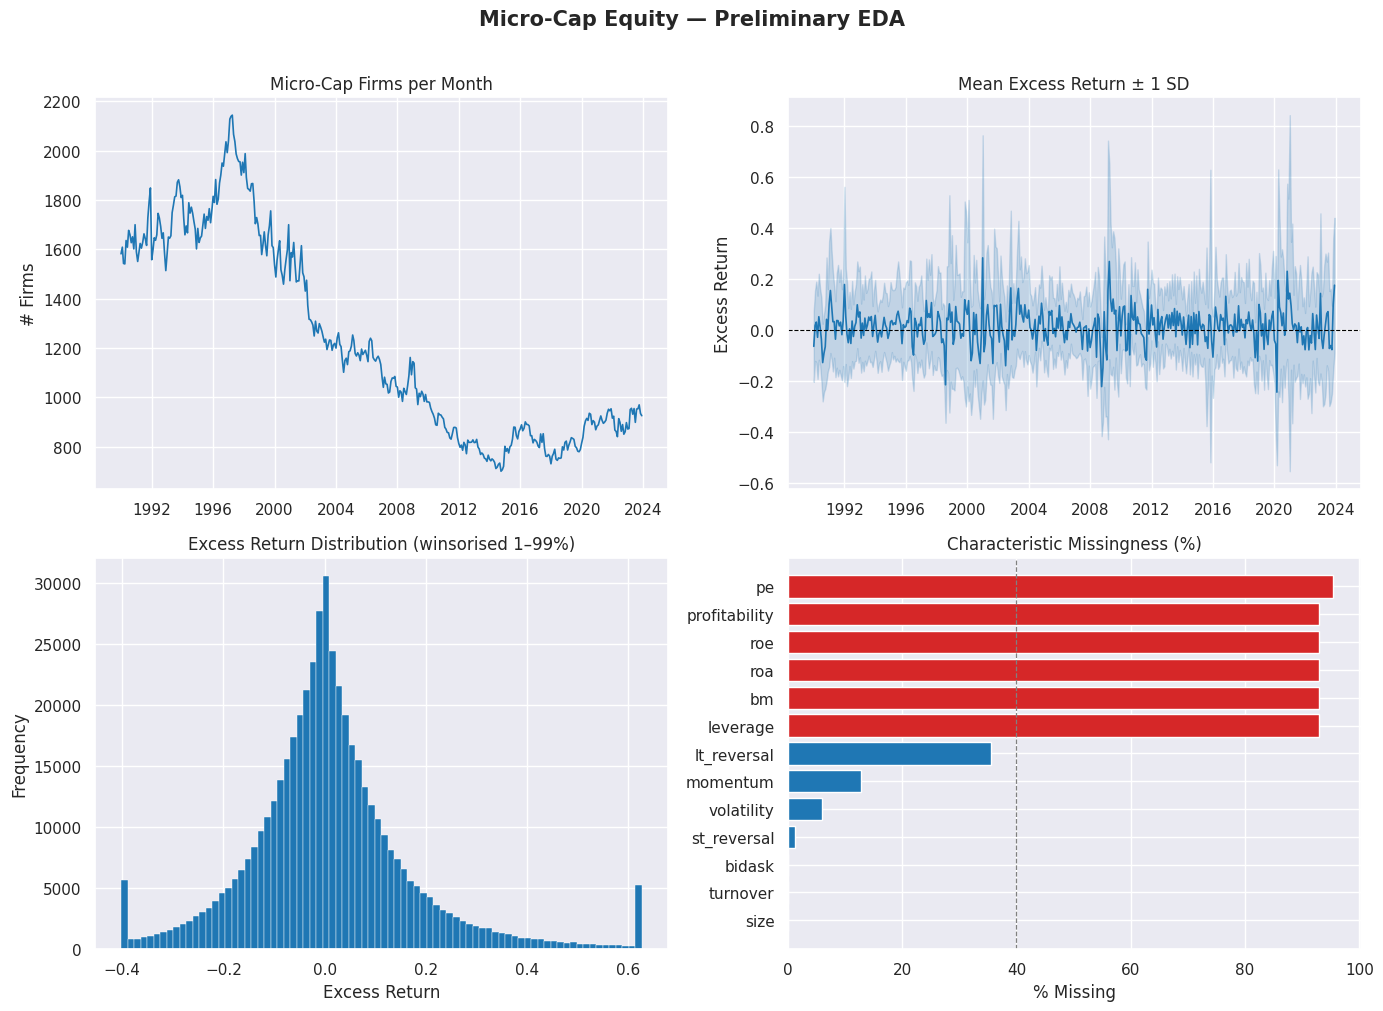

In [ ]:
sns.set_theme(style="darkgrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Micro-Cap Equity — Preliminary EDA", fontsize=15, fontweight="bold", y=1.01)

mc = df[df["is_microcap"]]

# 1. firms per month
firms_pm = mc.groupby("month")["permno"].nunique()
axes[0,0].plot(firms_pm.index, firms_pm.values, color="#1f77b4", lw=1.2)
axes[0,0].set_title("Micro-Cap Firms per Month")
axes[0,0].set_ylabel("# Firms")

# 2. mean excess return over time
monthly_ret = mc.groupby("month")["excess_ret"].agg(["mean","std"])
axes[0,1].fill_between(monthly_ret.index,
                        monthly_ret["mean"] - monthly_ret["std"],
                        monthly_ret["mean"] + monthly_ret["std"],
                        alpha=0.2, color="#1f77b4")
axes[0,1].plot(monthly_ret.index, monthly_ret["mean"], color="#1f77b4", lw=1.2)
axes[0,1].axhline(0, color="black", lw=0.8, ls="--")
axes[0,1].set_title("Mean Excess Return ± 1 SD")
axes[0,1].set_ylabel("Excess Return")

# 3. excess return distribution
mc["excess_ret"].clip(mc["excess_ret"].quantile(0.01),
                      mc["excess_ret"].quantile(0.99)).plot.hist(
    ax=axes[1,0], bins=80, color="#1f77b4", edgecolor="white", lw=0.3
)
axes[1,0].set_title("Excess Return Distribution (winsorised 1–99%)")
axes[1,0].set_xlabel("Excess Return")
axes[1,0].set_ylabel("Frequency")

# 4. characteristic missingness
chars = ["size","turnover","bidask","volatility","bm","pe",
         "roa","roe","profitability","leverage","momentum","st_reversal","lt_reversal"]
miss = mc[chars].isnull().mean().mul(100).sort_values(ascending=True)
colors = ["#d62728" if v > 40 else "#1f77b4" for v in miss.values]
axes[1,1].barh(miss.index, miss.values, color=colors, edgecolor="white")
axes[1,1].axvline(40, color="grey", ls="--", lw=0.9)
axes[1,1].set_title("Characteristic Missingness (%)")
axes[1,1].set_xlabel("% Missing")

plt.tight_layout()
plt.show()

In [3]:
from sqlalchemy import create_engine
engine = create_engine(DB_URL)

crsp   = pd.read_sql_table("crsp_monthly", engine, schema="raw", parse_dates=["date"])
rf     = pd.read_sql_table("rf", engine, schema="raw", parse_dates=["date"])
comp   = pd.read_sql_table("compustat_annual", engine, schema="raw", parse_dates=["datadate"])
bidask = pd.read_sql_table("bidask", engine, schema="raw", parse_dates=["date"])

print("loaded shapes:", crsp.shape, rf.shape, comp.shape, bidask.shape)

loaded shapes: (2021395, 17) (408, 3) (316956, 11) (3084239, 4)


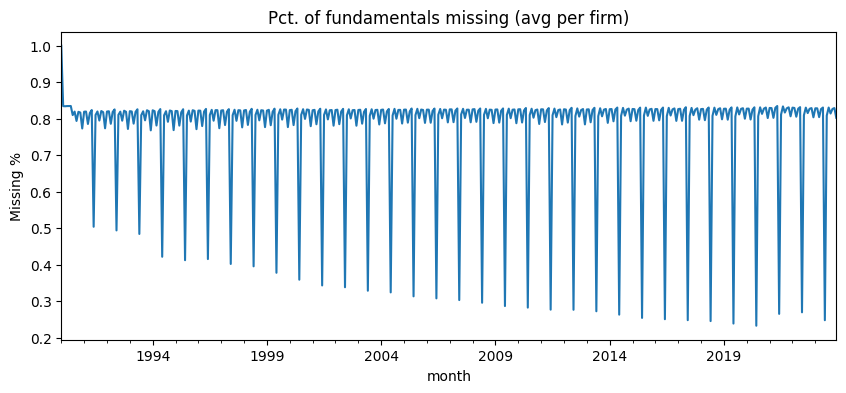

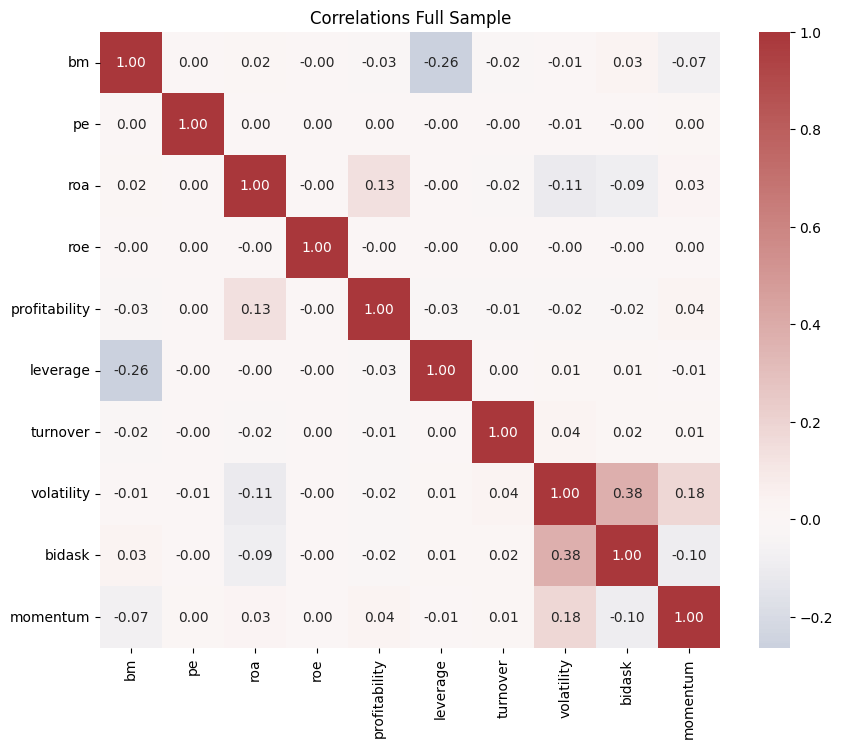

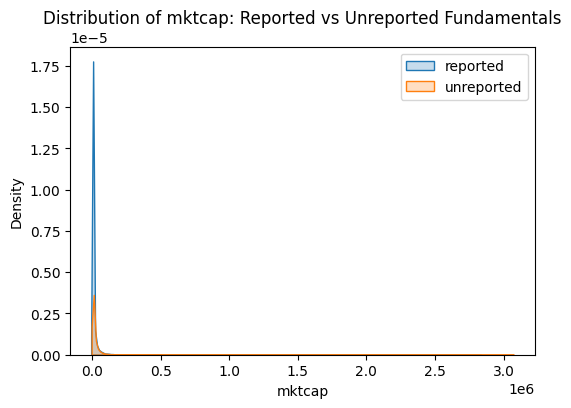

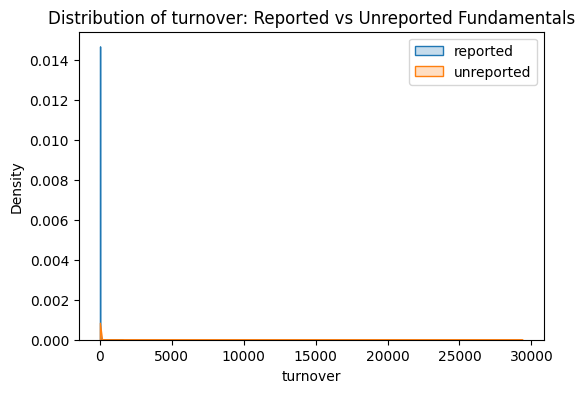

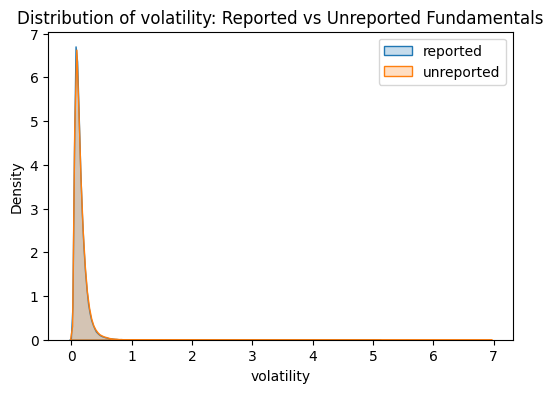

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

#allign dates to month start for consistent merging
for d in [crsp, rf, comp, bidask]:
    date_col = 'date' if 'date' in d.columns else 'datadate'
    d["month"] = pd.to_datetime(d[date_col]).dt.to_period('M').dt.to_timestamp()

#merge *fix in pipeline later*
df = crsp.merge(rf[["month", "rf"]], on="month", how="left")
if 'rf_y' in df.columns:
    df['rf'] = df['rf_y'].combine_first(df['rf_x'])
    df = df.drop(columns=['rf_x', 'rf_y'])

df["excess_ret"] = df["ret"] - df["rf"]

# Merge Bid-Ask 
df = df.merge(bidask[["permno", "month", "bidask"]], on=["permno", "month"], how="left")
if 'bidask_y' in df.columns:
    df['bidask'] = df['bidask_y'].combine_first(df['bidask_x'])
    df = df.drop(columns=['bidask_x', 'bidask_y'])

#lag data 6 month *compustat*
comp["merge_month"] = (comp["month"] + pd.DateOffset(months=6))
comp["cusip8"] = comp["cusip"].str[:8]
df["cusip8"]   = df["cusip"].str[:8]

# query: total_assets, book_equity, net_income, 
# gross_profit, long_term_debt, short_term_debt
comp_cols = ["cusip8", "merge_month", "total_assets", "book_equity", 
             "net_income", "gross_profit", "long_term_debt", "short_term_debt"]

df = df.merge(
    comp[comp_cols],
    left_on=["cusip8", "month"], 
    right_on=["cusip8", "merge_month"], 
    how="left"
)

# 4. characteristic construction
df = df.sort_values(["permno", "month"])
group = df.groupby("permno")

# Size Lag
df["mktcap_lag"] = group["mktcap"].shift(1)
df["size"]       = np.log(df["mktcap_lag"])

# Fundamentals
df["bm"]            = df["book_equity"] / df["mktcap_lag"]
df["pe"]            = df["mktcap_lag"] / df["net_income"]
df["roa"]           = df["net_income"] / df["total_assets"]
df["roe"]           = df["net_income"] / df["book_equity"]
df["profitability"] = df["gross_profit"] / df["total_assets"]
df["leverage"]      = (df["long_term_debt"].fillna(0) + df["short_term_debt"].fillna(0)) / df["mktcap_lag"]

# Market Dynamics
df["turnover"]    = group["vol"].shift(1) / group["shrout"].shift(1)
df["volatility"]  = group["ret"].transform(lambda x: x.shift(1).rolling(12).std())
df["momentum"]    = group["ret"].transform(lambda x: x.shift(2).rolling(11).apply(lambda r: (1+r).prod()-1, raw=True))
df["st_reversal"] = group["ret"].shift(1)
df["lt_reversal"] = group["ret"].transform(lambda x: x.shift(13).rolling(24).apply(lambda r: (1+r).prod()-1, raw=True))

# eda for fundementals and market dynamics
fund_cols = ["bm","pe","roa","roe","profitability","leverage"]

#Missingness Patterns
plt.figure(figsize=(10,4))
df[fund_cols].isna().mean(axis=1).groupby(df["month"]).mean().plot(title="Pct. of fundamentals missing (avg per firm)")
plt.ylabel("Missing %")
plt.show()

#Correlation Heatmap
plt.figure(figsize=(10,8))
corr_all = df[fund_cols + ["turnover","volatility","bidask","momentum"]].corr()
sns.heatmap(corr_all, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlations Full Sample")
plt.show()

#Distributions Reported vs Unreported
for col in ["mktcap","turnover","volatility"]:
    plt.figure(figsize=(6,4))
    reported = df["book_equity"].notna()
    sns.kdeplot(df.loc[reported, col].dropna(), label="reported", fill=True)
    sns.kdeplot(df.loc[~reported, col].dropna(), label="unreported", fill=True)
    plt.title(f"Distribution of {col}: Reported vs Unreported Fundamentals")
    plt.legend(); plt.show()

# Predictive Cross Sectional Regression
cs = df.dropna(subset=["excess_ret", "turnover", "volatility"]).copy()
cs["next_ret"] = cs.groupby("permno")["excess_ret"].shift(-1)
cs = cs.dropna(subset=["next_ret"])
X = sm.add_constant(cs[["turnover", "volatility"]])
print(sm.OLS(cs["next_ret"], X).fit().summary())


# Missingness Indicator Correlations
for col in fund_cols:
    df[f"{col}_miss"] = df[col].isna().astype(int)
miss_ret = df[[f"{c}_miss" for c in fund_cols] + ["excess_ret"]].corr()["excess_ret"]
print("\nCorrelation of Missingness Indicators with Excess Returns:\n", miss_ret.sort_values())

Calculating NYSE thresholds...
Total Rows: 2021395
Micro-Cap Rows: 1161819
Aggregating into monthly portfolios...
Fetching Fama-French factors...

CORRECTED FAMA-FRENCH RESULTS (True Micro-Caps)
                            OLS Regression Results                            
Dep. Variable:               micro_vw   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     1202.
Date:                Tue, 03 Mar 2026   Prob (F-statistic):          1.41e-200
Time:                        01:37:34   Log-Likelihood:                 1009.4
No. Observations:                 407   AIC:                            -2011.
Df Residuals:                     403   BIC:                            -1995.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
               

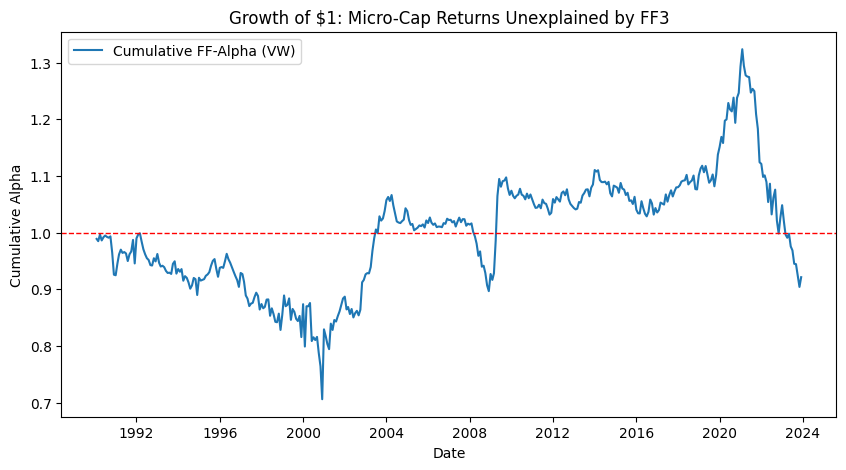

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. PREPARE DATA & ALIGN DATES
# -------------------------------------------------------------------------
for d in [crsp, rf]:
    date_col = 'date' if 'date' in d.columns else 'datadate'
    d["month"] = pd.to_datetime(d[date_col]).dt.to_period('M').dt.to_timestamp()

# Merge RF and calculate excess returns
df = crsp.merge(rf[["month", "rf"]], on="month", how="left")
if 'rf_y' in df.columns:
    df['rf'] = df['rf_y'].combine_first(df['rf_x'])
    df = df.drop(columns=['rf_x', 'rf_y'])
df["excess_ret"] = df["ret"] - df["rf"]

# 2. DEFINE MICRO-CAP UNIVERSE (The missing piece)
# -------------------------------------------------------------------------
# Calculate mktcap_lag (Standard to avoid look-ahead bias)
df = df.sort_values(['permno', 'month'])
df['mktcap_lag'] = df.groupby('permno')['mktcap'].shift(1)

print("Calculating NYSE thresholds...")
# Define micro-caps using the 20th percentile of NYSE stocks (exchcd == 1)
def get_nyse_thresholds(group):
    nyse_stocks = group[group['exchcd'] == 1]['mktcap_lag'].dropna()
    if len(nyse_stocks) == 0: return np.nan
    return np.percentile(nyse_stocks, 20)

nyse_cuts = df.groupby('month').apply(get_nyse_thresholds).rename("micro_cutoff")
df = df.merge(nyse_cuts, on='month', how='left')

# Filter for micro-caps only
micro_df = df[df['mktcap_lag'] <= df['micro_cutoff']].dropna(subset=['excess_ret', 'mktcap_lag']).copy()

print(f"Total Rows: {len(df)}")
print(f"Micro-Cap Rows: {len(micro_df)}")

# 3. AGGREGATE TO MONTHLY PORTFOLIOS
# -------------------------------------------------------------------------
print("Aggregating into monthly portfolios...")
portfolio_rets = micro_df.groupby('month').apply(
    lambda x: pd.Series({
        'micro_ew': x['excess_ret'].mean(),
        'micro_vw': np.average(x['excess_ret'], weights=x['mktcap_lag'])
    })
).reset_index()

# 4. FETCH FAMA-FRENCH FACTORS MANUALLY
# -------------------------------------------------------------------------
print("Fetching Fama-French factors...")
ff_url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip"
ff_factors = pd.read_csv(ff_url, compression='zip', skiprows=3, index_col=0)

stop_idx = ff_factors.index.get_loc(' Annual Factors: January-December ')
ff_factors = ff_factors.iloc[:stop_idx].copy()
ff_factors.index = pd.to_datetime(ff_factors.index, format='%Y%m').to_period('M').to_timestamp()
ff_factors = ff_factors.astype(float) / 100
ff_factors = ff_factors.reset_index().rename(columns={'index': 'month'})

# 5. MERGE AND RUN REGRESSION
# -------------------------------------------------------------------------
analysis_df = portfolio_rets.merge(ff_factors, on='month', how='inner')

# Regression for Value-Weighted Micro-Caps
Y = analysis_df['micro_vw']
X = sm.add_constant(analysis_df[['Mkt-RF', 'SMB', 'HML']])
ff_model = sm.OLS(Y, X).fit()

print("\n" + "="*50)
print("CORRECTED FAMA-FRENCH RESULTS (True Micro-Caps)")
print("="*50)
print(ff_model.summary())

#visualize cumulative alpha over time
analysis_df['cum_alpha'] = (1 + ff_model.resid).cumprod()

plt.figure(figsize=(10, 5))
plt.plot(analysis_df['month'], analysis_df['cum_alpha'], label='Cumulative FF-Alpha (VW)')
plt.axhline(1, color='red', lw=1, ls='--')
plt.title("Growth of $1: Micro-Cap Returns Unexplained by FF3")
plt.xlabel("Date")
plt.ylabel("Cumulative Alpha")
plt.legend()
plt.show()

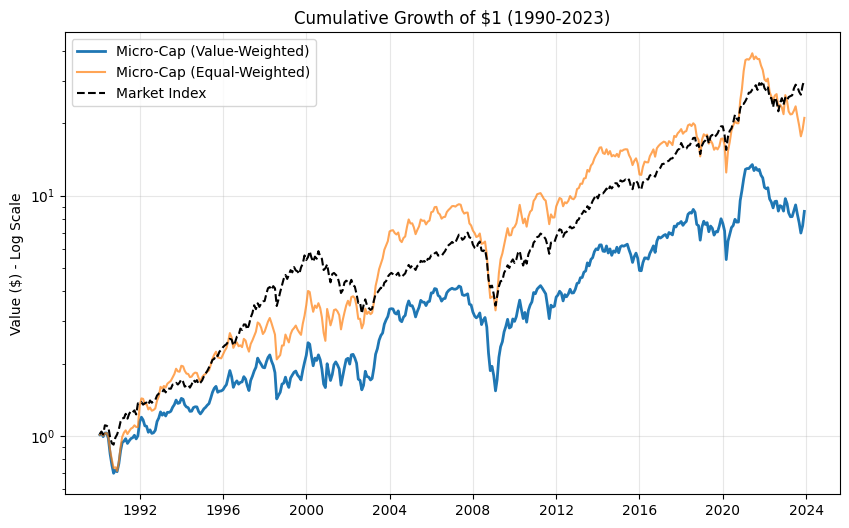

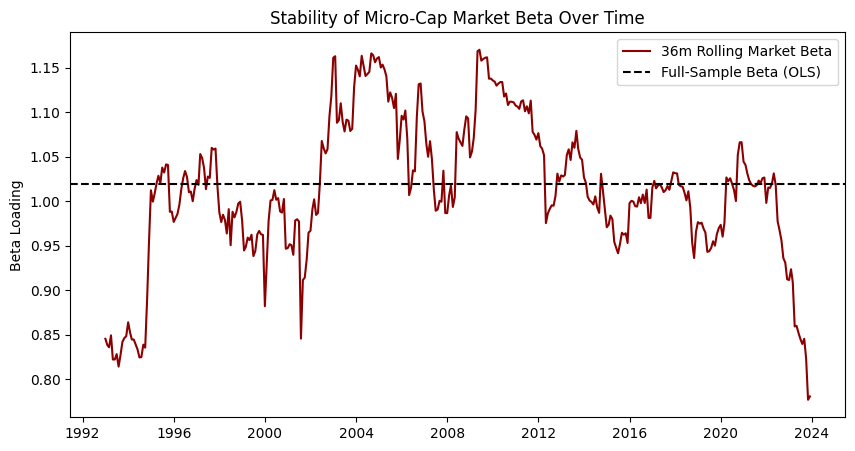

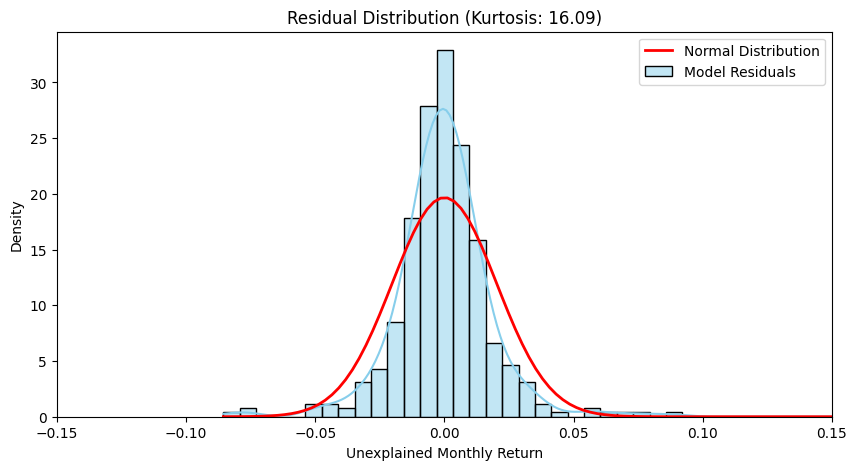

In [ ]:
import scipy.stats as stats

# 1. cumulative performance plot (log scale)
plt.figure(figsize=(10, 6))
analysis_df['cum_vw'] = (1 + analysis_df['micro_vw']).cumprod()
analysis_df['cum_ew'] = (1 + analysis_df['micro_ew']).cumprod()
analysis_df['cum_mkt'] = (1 + analysis_df['Mkt-RF'] + analysis_df['RF']).cumprod()

plt.plot(analysis_df['month'], analysis_df['cum_vw'], label='Micro-Cap (Value-Weighted)', lw=2)
plt.plot(analysis_df['month'], analysis_df['cum_ew'], label='Micro-Cap (Equal-Weighted)', lw=1.5, alpha=0.7)
plt.plot(analysis_df['month'], analysis_df['cum_mkt'], label='Market Index', color='black', ls='--', lw=1.5)

plt.yscale('log')
plt.title("Cumulative Growth of $1 (1990-2023)")
plt.ylabel("Value ($) - Log Scale")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. rolling factor loadings 36 month window
def get_rolling_beta(window):
    Y_w = window['micro_vw']
    X_w = sm.add_constant(window[['Mkt-RF', 'SMB', 'HML']])
    return sm.OLS(Y_w, X_w).fit().params['Mkt-RF']

rolling_beta = [np.nan]*35 
for i in range(36, len(analysis_df)+1):
    window = analysis_df.iloc[i-36:i]
    rolling_beta.append(get_rolling_beta(window))

plt.figure(figsize=(10, 5))
plt.plot(analysis_df['month'], rolling_beta, color='darkred', label='36m Rolling Market Beta')
plt.axhline(ff_model.params['Mkt-RF'], color='black', ls='--', label='Full-Sample Beta (OLS)')
plt.title("Stability of Micro-Cap Market Beta Over Time")
plt.ylabel("Beta Loading")
plt.legend()
plt.show()

# 3. residual dist (Visualizing the 18.8 Kurtosis)
plt.figure(figsize=(10, 5))
residuals = ff_model.resid
sns.histplot(residuals, kde=True, stat="density", color="skyblue", label="Model Residuals")

# overlay perf normal dist 
x = np.linspace(residuals.min(), residuals.max(), 100)
plt.plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()), 
         color='red', lw=2, label='Normal Distribution')

plt.title(f"Residual Distribution (Kurtosis: {residuals.kurtosis():.2f})")
plt.xlabel("Unexplained Monthly Return")
plt.xlim(-0.15, 0.15)
plt.legend()
plt.show()